# Study Gauss
[PyMC公式ライブラリ](https://www.pymc.io/projects/docs/en/stable/installation.html)

[ガウス過程回帰モデルの基礎](https://gochikika.ntt.com/Modeling/gp_regression.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ガウス過程
## 定義
$$
f(x) \sim \mathcal{GP}(m(x), k(x, x'))
$$

## カーネルの種類
| 名前 | 特徴 | 数式 |
|------|------|------|
| RBF | 滑らか | $$k(x, x') = \sigma^2 \exp\left( -\frac{(x - x')^2}{2\ell^2} \right)$$ |
| Exponential kernel | 粗い | $$k(x, x') = \sigma^2 \exp\left( -\frac{|x - x'|}{\ell} \right)$$ |
| Matérn | RBFとExの中間 | $$k(x, x') = \sigma^2 \frac{2^{1-\nu}}{\Gamma(\nu)} \left( \frac{\sqrt{2\nu}\,|x - x'|}{\ell} \right)^\nu K_\nu\!\left( \frac{\sqrt{2\nu}\,|x - x'|}{\ell} \right)$$ |
| Periodic kernel | 周期 | $$k(x, x') = \sigma^2 \exp\left( -\frac{2 \sin^2\left( \frac{\pi |x - x'|}{p} \right)}{\ell^2} \right)$$ |
| Linear kernel | トレンド | $$k(x, x') = \sigma_b^2 + \sigma_v^2 (x - c)(x' - c)$$ |
| Rational Quadratic | 複数スケール | $$k(x, x') = \sigma^2 \left( 1 + \frac{(x - x')^2}{2\alpha \ell^2} \right)^{-\alpha}$$ |
| Power-law | 長期記憶 | $$k(x, x') = \frac{\sigma^2}{(1 + |x - x'|)^\gamma}$$ |

```python
x = np.linspace(0, 20, n_points)[:, None]
```
$$
\Delta x = x_{i+1} - x_{i} = \frac{20}{n_{point} - 1}
$$

In [2]:
# input
np.random.seed(42)
x = np.linspace(0, 40, 100)[:, None]   # Delta x = 0.4

In [3]:
# distance
def pairwise_dist(X1, X2):
    return np.abs(X1 - X2.T)

def pairwise_sqdist(X1, X2):
    return (X1 - X2.T) ** 2

In [4]:
# kernel
def kernel_rbf(X1, X2, sigma=1.0, ell=1.0):
    sqdist = pairwise_sqdist(X1, X2)
    return sigma**2 * np.exp(-0.5 * sqdist / ell**2)

def kernel_exponential(X1, X2, sigma=1.0, ell=1.0):
    dist = pairwise_dist(X1, X2)
    return sigma**2 * np.exp(-dist / ell)

def kernel_matern12(X1, X2, sigma=1.0, ell=1.0):
    # Matern ν=1/2 = Exponential
    dist = pairwise_dist(X1, X2)
    return sigma**2 * np.exp(-dist / ell)

def kernel_matern32(X1, X2, sigma=1.0, ell=1.0):
    dist = pairwise_dist(X1, X2)
    z = np.sqrt(3) * dist / ell
    return sigma**2 * (1 + z) * np.exp(-z)

def kernel_matern52(X1, X2, sigma=1.0, ell=1.0):
    dist = pairwise_dist(X1, X2)
    z = np.sqrt(5) * dist / ell
    return sigma**2 * (1 + z + z**2 / 3) * np.exp(-z)

def kernel_periodic(X1, X2, sigma=1.0, ell=1.0, p=4.0):
    dist = pairwise_dist(X1, X2)
    return sigma**2 * np.exp(-2 * (np.sin(np.pi * dist / p) ** 2) / ell**2)

def kernel_linear(X1, X2, sigma_b=1.0, sigma_v=1.0, c=0.0):
    return sigma_b**2 + sigma_v**2 * ((X1 - c) @ (X2 - c).T)

def kernel_rational_quadratic(X1, X2, sigma=1.0, ell=1.0, alpha=1.0):
    sqdist = pairwise_sqdist(X1, X2)
    return sigma**2 * (1 + sqdist / (2 * alpha * ell**2)) ** (-alpha)

def kernel_power_law_like(X1, X2, sigma=1.0, gamma=0.7):
    """
    厳密な標準GPカーネルというより、研究用の簡易な長距離相関の可視化用。
    相関 ~ (1 + |t-s|)^(-gamma) としたもの。
    gamma が小さいほど長期記憶っぽい。
    """
    dist = pairwise_dist(X1, X2)
    return sigma**2 / ((1 + dist) ** gamma)

In [5]:
# kernel , mean => gauss samples
def sample_gp(K, mean=None ,n_samples=5, jitter=1e-6):
    n = K.shape[0] # size kernel
    K_stable = K + jitter * np.eye(n) # positive definite
    if mean is None:
        mean = np.zeros(n)
    return np.random.multivariate_normal(mean, K_stable, size=n_samples)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sample_acf(series, max_lag=30):
    x = np.asarray(series, dtype=float)
    x = x - np.mean(x)
    n = len(x)

    denom = np.dot(x, x)
    if denom <= 0:
        return np.zeros(max_lag + 1)

    acf_vals = [1.0]
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acf_vals.append(num / denom)

    return np.array(acf_vals)

def plot_kernel_samples_and_acf(x, K, samples, title, max_lag=30):
    max_lag = int(max_lag)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. covariance matrix
    im = axes[0].imshow(K, origin="upper", aspect="auto")
    axes[0].set_title(f"{title} covariance")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # 2. prior samples
    for i in range(samples.shape[0]):
        if i >= 3:
            break
        axes[1].plot(x.ravel(), samples[i], lw=1.5)
    axes[1].set_title(f"{title} prior samples")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("f(x)")
    axes[1].grid(True, alpha=0.3)

    # 3. sample ACF of the last sample
    acf_list = []
    for s in samples:
        acf_s = sample_acf(s, max_lag=max_lag)
        acf_list.append(acf_s)

    acf_array = np.array(acf_list)

    acf_mean = acf_array.mean(axis=0)
    acf_std = acf_array.std(axis=0)

    lags = np.arange(max_lag + 1)

    axes[2].plot(lags, acf_mean, label="mean ACF")
    axes[2].fill_between(
        lags,
        acf_mean - acf_std,
        acf_mean + acf_std,
        alpha=0.3,
        label="±1 std"
    )

    axes[2].axhline(0.0, color="black", lw=1)
    axes[2].set_title(f"{title} sample ACF (mean ± std)")
    axes[2].set_xlabel("lag")
    axes[2].set_ylabel("ACF")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

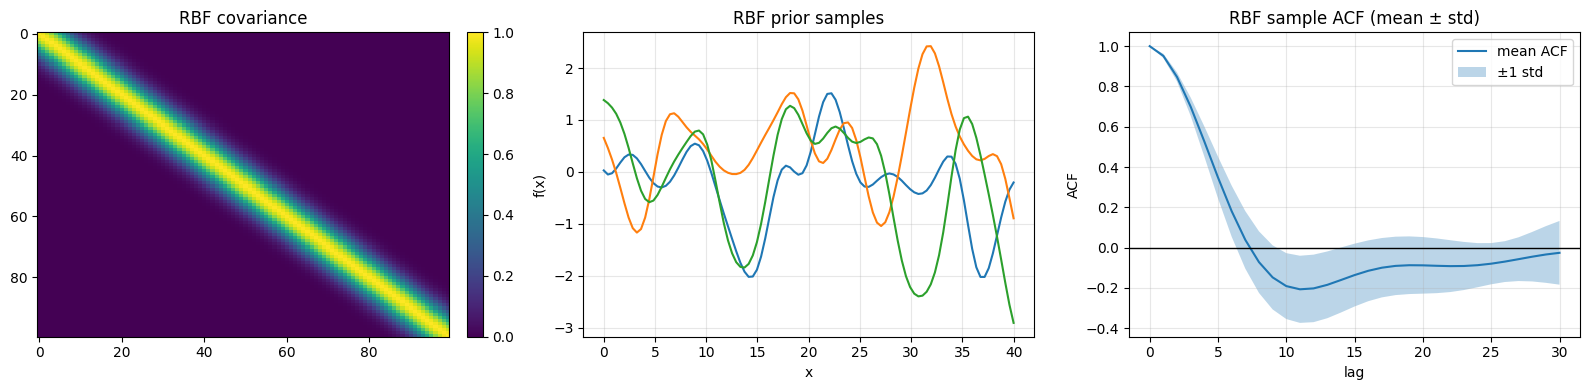

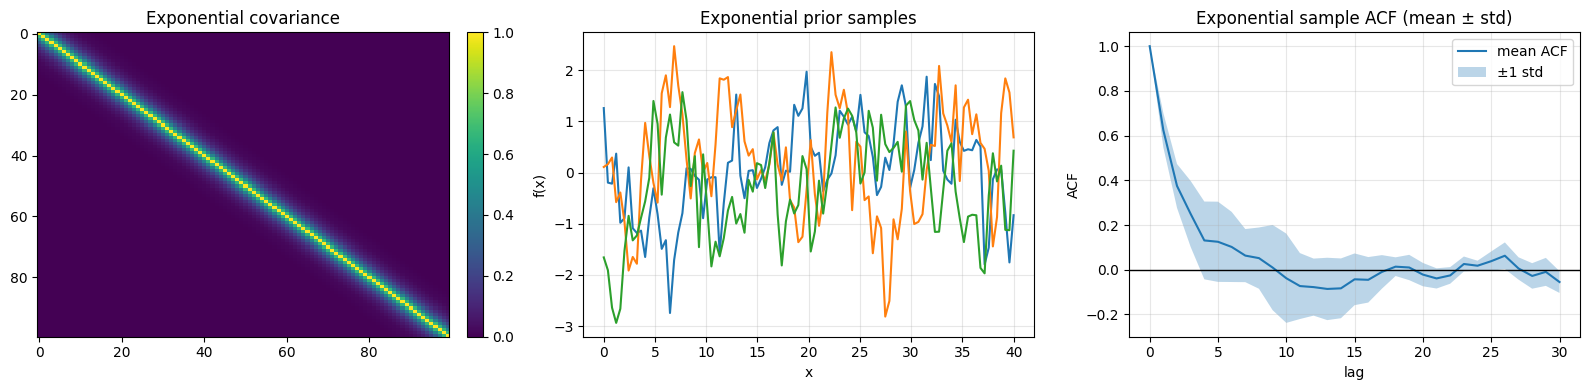

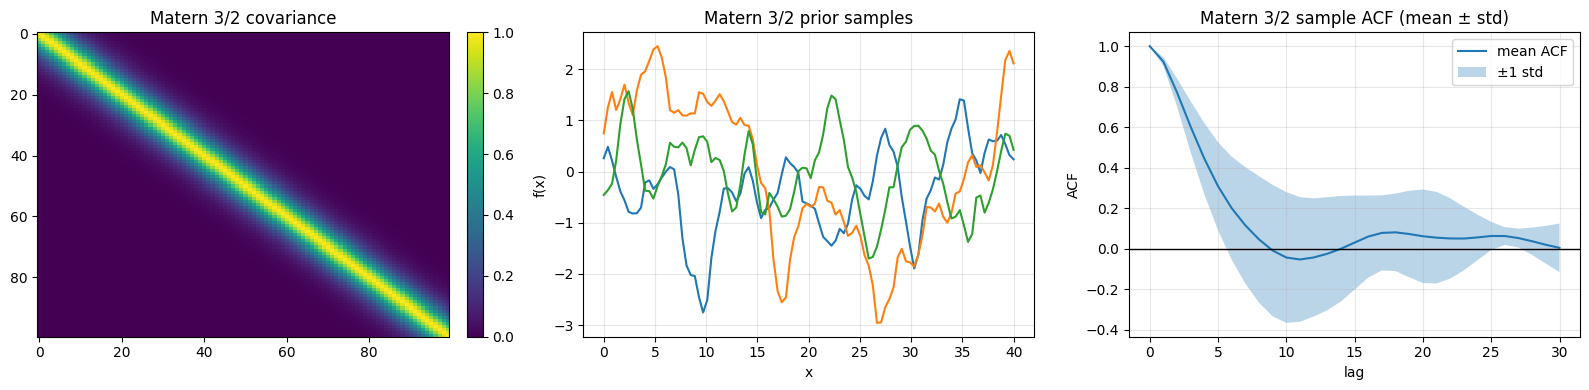

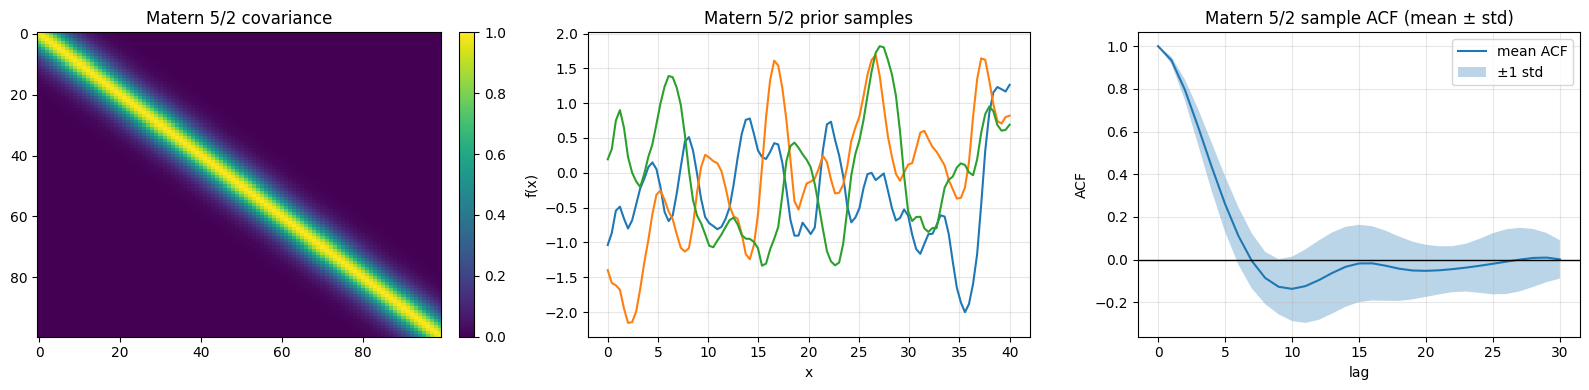

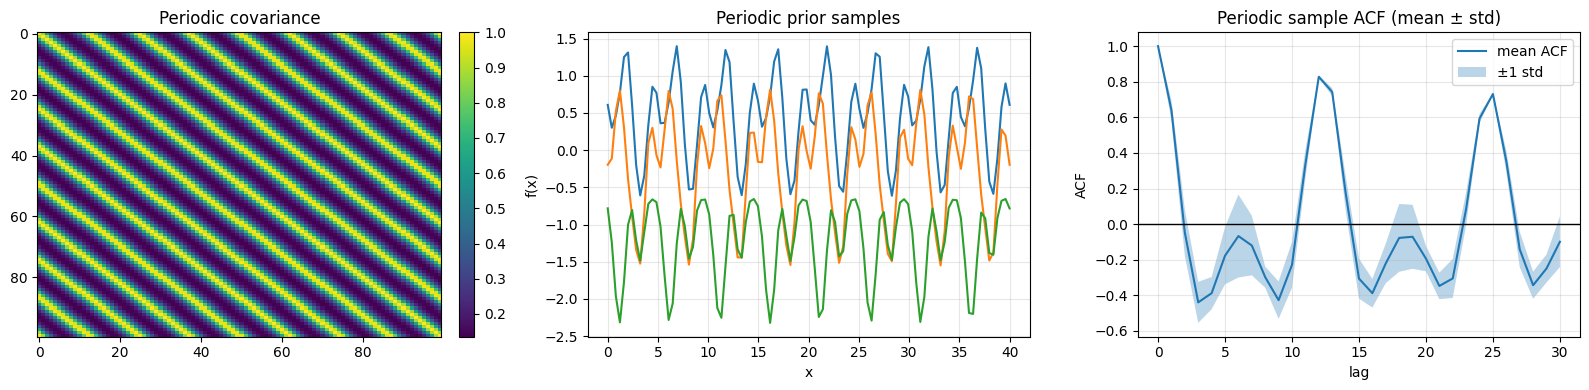

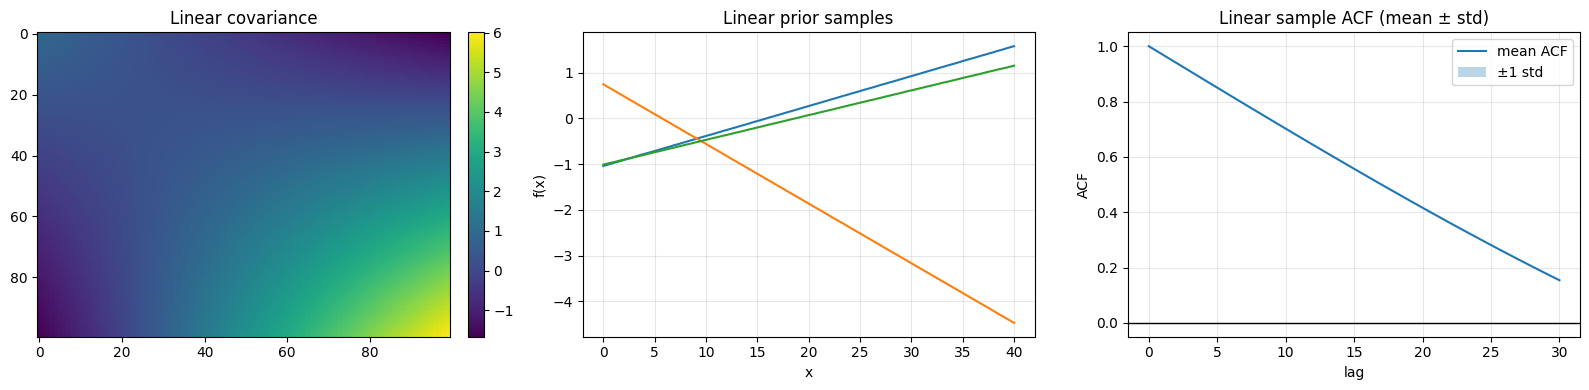

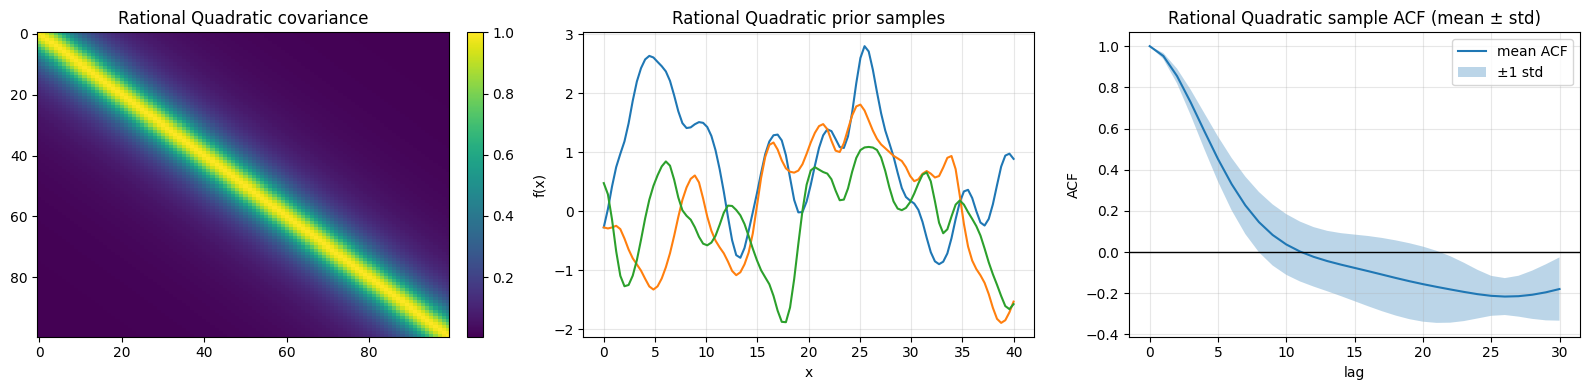

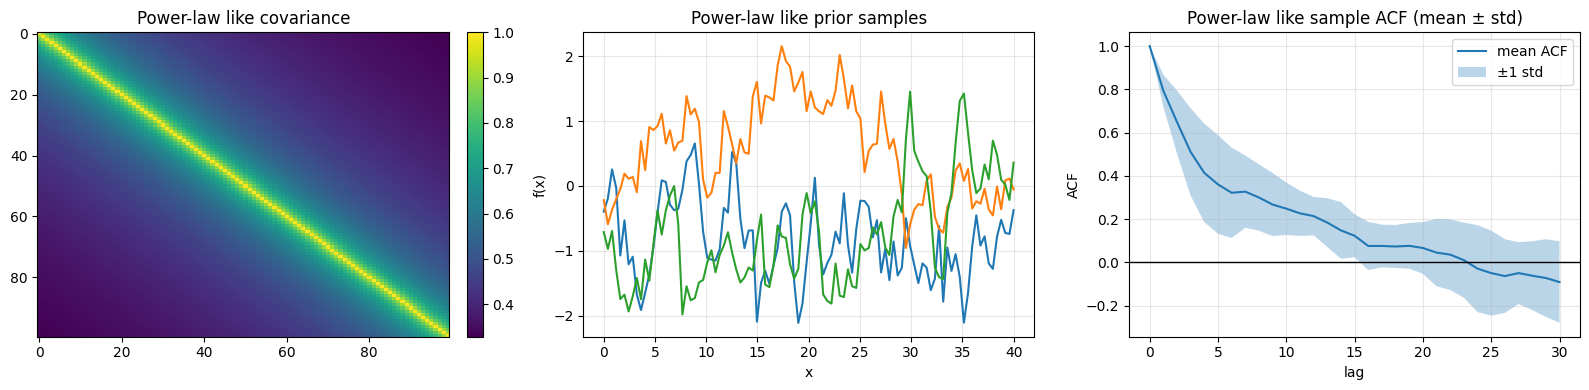

In [7]:
kernels = {
    "RBF": kernel_rbf(x, x, sigma=1.0, ell=2.0),
    "Exponential": kernel_exponential(x, x, sigma=1.0, ell=1.0),
    "Matern 3/2": kernel_matern32(x, x, sigma=1.0, ell=2.0),
    "Matern 5/2": kernel_matern52(x, x, sigma=1.0, ell=2.0),
    "Periodic": kernel_periodic(x, x, sigma=1.0, ell=1.0, p=5.0),
    "Linear": kernel_linear(x, x, sigma_b=0.5, sigma_v=0.08, c=10.0),
    "Rational Quadratic": kernel_rational_quadratic(x, x, sigma=1.0, ell=2.0, alpha=1.0),
    "Power-law like": kernel_power_law_like(x, x, sigma=1.0, gamma=0.3),
}

for name, K in kernels.items():
    samples = sample_gp(K, n_samples=5, jitter=1e-6)
    plot_kernel_samples_and_acf(x, K, samples, name, max_lag=30)

In [8]:
# input
np.random.seed(42)
x = np.linspace(0, 100, 100)[:, None]   # Delta x = 0.4

## 潜在変数そのものの性質

### 標本自己相関

In [9]:
def pairwise_dist(X1, X2):
    return np.abs(X1 - X2.T)

def pairwise_sqdist(X1, X2):
    return (X1 - X2.T) ** 2

指数カーネル
$$
k(x, x') = \sigma^2 \exp\left(-\frac{|x - x'|}{\ell}\right)
$$

自己相関
$$
\rho(h) \sim \theta^h
$$

In [10]:
def kernel_exponential(X1, X2, sigma=1.0, ell=1.0):
    dist = pairwise_dist(X1, X2)
    return sigma**2 * np.exp(-dist / ell)

べき乗カーネル
$$
k(x, x') = \frac{\sigma^2}{(1 + |x - x'|)^{\gamma}}
$$
自己相関
$$
\rho(h) \sim h^{-\gamma}
$$

In [11]:
np.exp(-1)

np.float64(0.36787944117144233)

In [12]:
def kernel_power_law_like(X1, X2, sigma=1.0, gamma=0.7):
    dist = pairwise_dist(X1, X2)
    return sigma**2 / ((1 + dist) ** gamma)

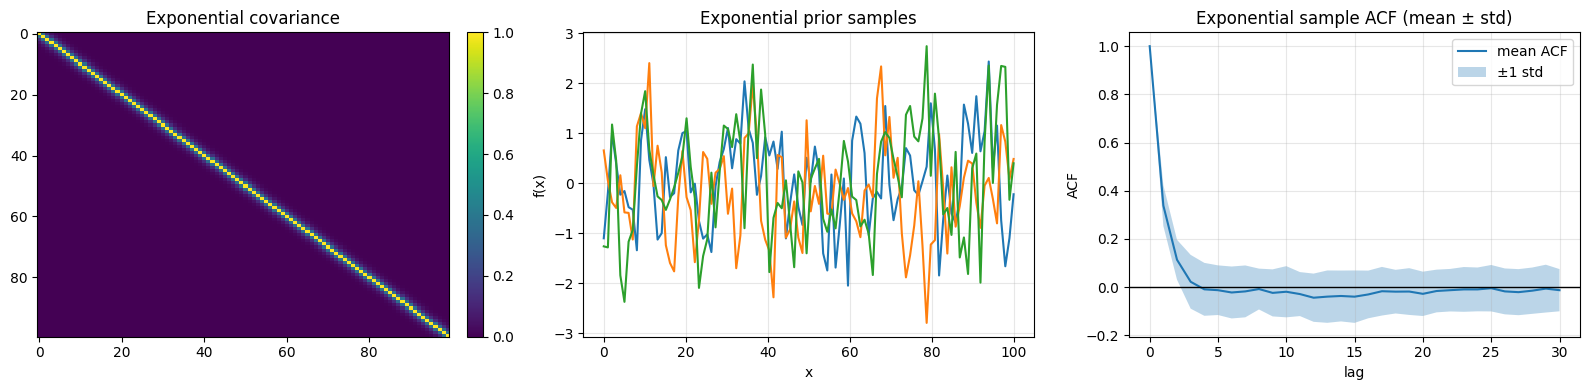

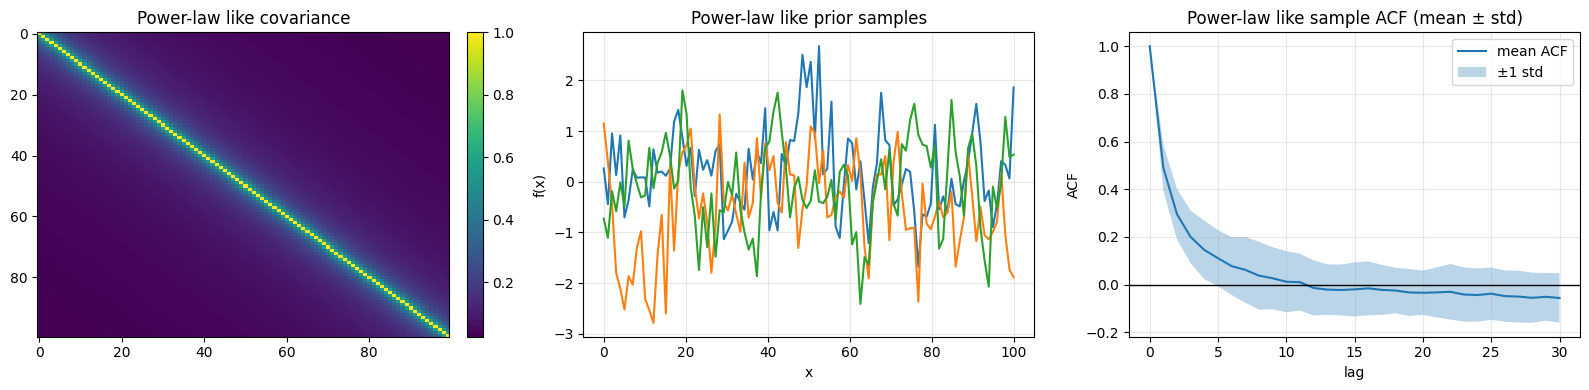

In [13]:
kernels = {
    "Exponential": kernel_exponential(x, x, sigma=1.0, ell=1.0),
    "Power-law like": kernel_power_law_like(x, x, sigma=1.0, gamma=0.8),
}

for name, K in kernels.items():
    samples = sample_gp(K, n_samples=100, jitter=1e-6)
    plot_kernel_samples_and_acf(x, K, samples, name, max_lag=30)

## 強度累積和の分散スケーリング

In [14]:
# input
np.random.seed(42)
x = np.linspace(0, 1000, 1000)[:, None]   # Delta x = 0.4

In [15]:
def to_intensity(samples, lambda0=1.0, alpha=1.0):
    """
    samples: shape (n_samples, T)
    return : shape (n_samples, T)
    """
    return lambda0 * np.exp(alpha * samples)

def cumulative_sum_variance(lam_samples):
    """
    lam_samples: shape (n_samples, T)
    return
        T_vals: shape (T,)
        var_vals: shape (T,)
    """
    cumsum = np.cumsum(lam_samples, axis=1)   # shape (n_samples, T)
    var_vals = np.var(cumsum, axis=0, ddof=1) # 各時点Tでサンプル間分散
    T_vals = np.arange(1, lam_samples.shape[1] + 1)
    return T_vals, var_vals

In [16]:
ex_K = kernel_exponential(x, x, sigma=1.0, ell=1.0)
ex_samples = sample_gp(ex_K, n_samples=100, jitter=1e-6)

pow_K = kernel_power_law_like(x, x, sigma=1.0, gamma=0.7)
pow_samples = sample_gp(pow_K, n_samples=100, jitter=1e-6)

lambda0 = 1.0
alpha = 1.0

ex_lambda = to_intensity(ex_samples, lambda0=lambda0, alpha=alpha)
pow_lambda = to_intensity(pow_samples, lambda0=lambda0, alpha=alpha)

T_ex, var_ex = cumulative_sum_variance(ex_lambda)
T_pow, var_pow = cumulative_sum_variance(pow_lambda)

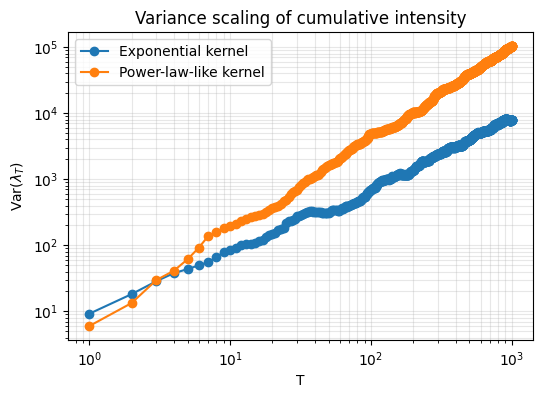

In [53]:
plt.figure(figsize=(6, 4))
plt.loglog(T_ex, var_ex, marker="o", label="Exponential kernel")
plt.loglog(T_pow, var_pow, marker="o", label="Power-law-like kernel")
plt.xlabel("T")
plt.ylabel("Var($\lambda_T$)")
plt.title("Variance scaling of cumulative intensity")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 有限サイズ指標
### 強度の総和の分散
$$
Var\left(\lambda_T = \sum^T_{t=1} \lambda_t \right) \simeq \bar{V}T + 2\bar{V}\sum^{T-1}_{i=1} d_i(T-i)
$$
ただし$\bar{V}=Var(\lambda_t)$

#### 指数減衰
$$
\text{Var}\left(\lambda_T = \sum^T_{t=1} \lambda_t \right) \simeq \bar{V}T + 2\bar{V}\sum^{T-1}_{i=1} \theta^i(T-i)
$$

$T \to \infty$の漸近領域の時

$$
\text{Var}(\lambda_t) \propto T \ ,\ \log{\text{Var}(\lambda_t) \propto \log{T}}
$$

#### べき乗減衰
$$
Var\left(\lambda_T = \sum^T_{t=1} \lambda_t \right) \simeq \bar{V}T + 2\bar{V}\sum^{T-1}_{i=1} \frac{T-i}{(1+i)^{\gamma}}
$$

$T \to \infty$の漸近領域の時

$(\gamma > 1)$
$$
\text{Var}(\lambda_t) \propto T \ ,\ \log{\text{Var}(\lambda_t) \propto \log{T}}
$$

$(\gamma = 1)$
$$
\text{Var}(\lambda_t) \propto T\log{T}
$$

$(\gamma < 1)$
$$
\text{Var}(\lambda_t) \propto T^{2-\gamma}\ ,\ \log{\text{Var}(\lambda_t) \propto (2-\gamma)\log{T}}
$$

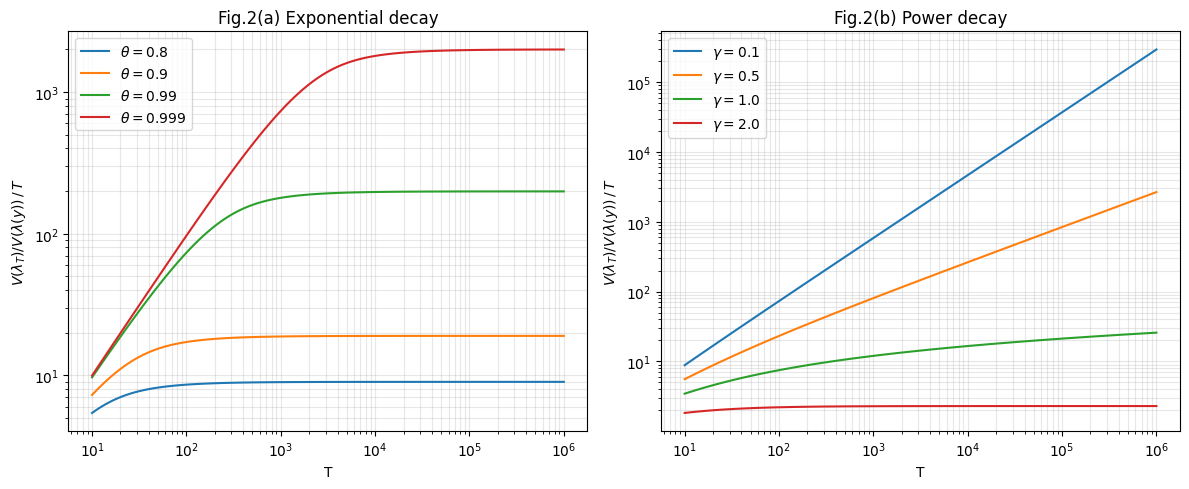

In [18]:
# -----------------------------
# Z_T = V(lambda_T) / V(lambda(y))
# 論文の式では Vbar が共通因子なので 1 としてよい
# -----------------------------
def z_exp(T, theta):
    i = np.arange(1, T)
    return T + 2.0 * np.sum((theta ** i) * (T - i))

def z_pow(T, gamma):
    i = np.arange(1, T)
    return T + 2.0 * np.sum(((i + 1.0) ** (-gamma)) * (T - i))

# -----------------------------
# Fig.2 再現
# -----------------------------
T_grid = np.unique(np.logspace(1, 6, 120).astype(int))  # 10 ~ 10000
theta_list = [0.8, 0.9, 0.99, 0.999]
gamma_list = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) exponential
for theta in theta_list:
    zvals = np.array([z_exp(T, theta) for T in T_grid], dtype=float)
    axes[0].loglog(T_grid, zvals / T_grid, label=fr"$\theta={theta}$")
axes[0].set_title("Fig.2(a) Exponential decay")
axes[0].set_xlabel("T")
axes[0].set_ylabel(r"$V(\lambda_T)/V(\lambda(y)) \,/\, T$")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

# (b) power
for gamma in gamma_list:
    zvals = np.array([z_pow(T, gamma) for T in T_grid], dtype=float)
    axes[1].loglog(T_grid, zvals / T_grid, label=fr"$\gamma={gamma}$")
axes[1].set_title("Fig.2(b) Power decay")
axes[1].set_xlabel("T")
axes[1].set_ylabel(r"$V(\lambda_T)/V(\lambda(y)) \,/\, T$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

**指数 vs べきは有限データでは区別が難しい**

そこで有限サイズ指標$\delta$を導入する。
$\text{Var}(\lambda_T) \propto T^{\beta}$として 

$$
\frac{\text{Var}({\lambda_T})}{\text{Var}(\lambda_{2T})} = 2^{-\beta}
$$

この対数-対数プロットが$-\beta$となり、$\delta < -1$で$\text{long memory}$と主張しやすい

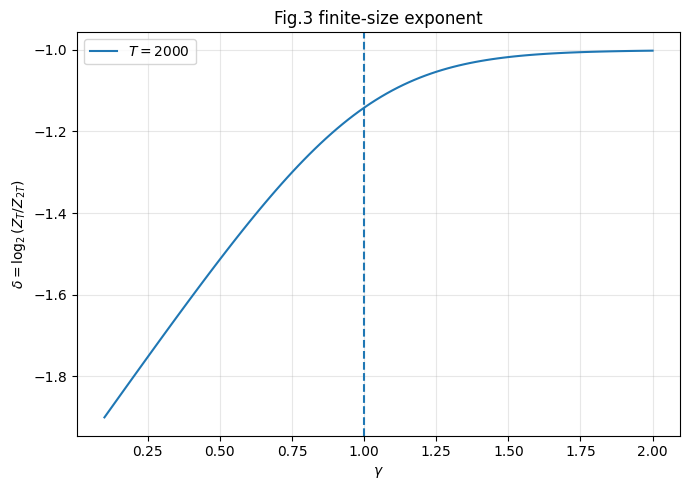

In [19]:
# -----------------------------
# Fig.3 再現
# delta = log2( Z_T / Z_2T )
# alpha は理論式上この比で消えるので、
# 論文の凡例 alpha=1.0, 0.5 は見た目上は一致しやすい
# -----------------------------
gamma_grid = np.linspace(0.1, 2.0, 100)
T0 = 2000

delta_vals = []
for gamma in gamma_grid:
    zT = z_pow(T0, gamma)
    z2T = z_pow(2 * T0, gamma)
    delta_vals.append(np.log2(zT / z2T))
delta_vals = np.array(delta_vals)

plt.figure(figsize=(7, 5))
plt.plot(gamma_grid, delta_vals, label=fr"$T={T0}$")
plt.axvline(1.0, linestyle="--")
plt.title("Fig.3 finite-size exponent")
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$\delta = \log_2(Z_T/Z_{2T})$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

データの主張例
- power-law decay model の方が exponential decay model より適合が良い
- 推定された$\gamma$ は 1 未満に位置し、長期相関を示唆する
- 有限サイズ指標も super-normal transition と整合的

In [20]:
def finite_size_indicator(var_vals):
    """
    var_vals: shape (T,)
    return
        T_base: T
        delta : log(Var(S_T) / Var(S_{2T}))
    """
    T_max = len(var_vals)
    T_base = np.arange(1, T_max // 2 + 1)
    delta = np.log(var_vals[T_base - 1] / var_vals[2 * T_base - 1])
    return T_base, delta

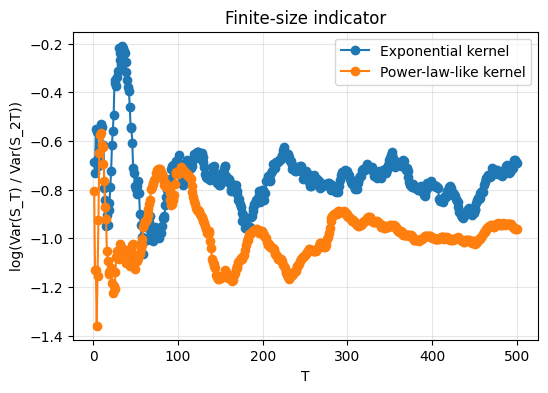

In [21]:
T_base_ex, delta_ex = finite_size_indicator(var_ex)
T_base_pow, delta_pow = finite_size_indicator(var_pow)

plt.figure(figsize=(6, 4))
plt.plot(T_base_ex, delta_ex, marker="o", label="Exponential kernel")
plt.plot(T_base_pow, delta_pow, marker="o", label="Power-law-like kernel")
plt.xlabel("T")
plt.ylabel("log(Var(S_T) / Var(S_2T))")
plt.title("Finite-size indicator")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

確認$\text{Var}(\lambda_T)\sim T^{\beta}$
$$
\delta=-\beta \log2
$$

$$
\to \beta = \frac{- \delta}{\log 2}
$$

## 新しいデータにおけるガウス過程
$$
\begin{pmatrix}
f(x) \\
f(x_*)
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
m(x) \\
m(x_*)
\end{pmatrix},
\begin{pmatrix}
k(x, x') & k(x, x_*) \\
k(x_*, x) & k(x_*, x_*)
\end{pmatrix}
\right)
$$

予測分布
$$
f(x_*) \mid f(x) \sim
\mathcal{N}
\left(
k(x_*, x) k(x, x)^{-1} (f(x) - m(x)) + m(x_*),
\;
k(x_*, x_*) - k(x_*, x) k(x, x)^{-1} k(x, x_*)
\right)
$$

# べき減衰を推定する
## 生成モデル
$$
y \sim \mathcal{N}(0, K), \quad 
K_{ij} = \sigma_y^2 (1 + |t_i - t_j|)^{-\gamma}
$$

$$
X_t \mid y_t \sim \text{Poisson}(\lambda_t), \quad 
\lambda_t = \exp(\eta_0 + \alpha y_t)
$$

試したいこと
- 指数減衰とべき乗減衰どちらのモデルが LFO で勝つか
- 推定$\hat{\gamma}$が真値の近くに来るか
- $\gamma$を変えると勝敗がどう変わるか

特に
$$
\gamma \in \{ 0.2 , 0.4 , 0.7 , 0.9 , 1.0 ,1.1 ,  1.5 , 2.0\}
$$

をシミュレーションして以下になることを期待したい
- $\gamma < 1$では power-law カーネル優位
- $\gamma \sim 1$では差が小さいか有限標本で曖昧
- $\gamma > 1$ではでは指数でもかなり近い
- 系列が短いと power-law の優位性は見えにくい

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# =========================
# 1. パラメータ設定
# =========================
np.random.seed(42)

start_year = 1920
end_year = 2020
years = np.arange(start_year, end_year + 1)
T = len(years)

lambda0 = 20.0      # ベース強度
eta0 = np.log(lambda0)
alpha = 0.8         # 潜在因子の効き方
gamma = 0.5       # 真の power-law 指数
sigma_y = 1.0       # 潜在過程の分散スケール
jitter = 1e-8       # 数値安定化

In [24]:
eta0

np.float64(2.995732273553991)

In [25]:

# =========================
# 2. power-law 共分散行列
# =========================
def power_law_covariance(t, gamma=0.7, sigma=1.0):
    """
    K_ij = sigma^2 / (1 + |t_i - t_j|)^gamma
    """
    t = np.asarray(t, dtype=float)
    dist = np.abs(t[:, None] - t[None, :])
    K = (sigma ** 2) / ((1.0 + dist) ** gamma)
    return K

t_index = np.arange(T)
K = power_law_covariance(t_index, gamma=gamma, sigma=sigma_y)

# jitter を足す
K = K + jitter * np.eye(T)

# 正定値チェック
eigvals = np.linalg.eigvalsh(K)
print("min eigenvalue =", eigvals.min())

# =========================
# 3. 潜在過程 y_t を生成
# =========================
y = np.random.multivariate_normal(mean=np.zeros(T), cov=K)

# =========================
# 4. 強度 lambda_t と Poisson カウント X_t を生成
# =========================
lam = np.exp(eta0 + alpha * y)
x = np.random.poisson(lam)

# =========================
# 5. データフレーム化
# =========================
df_sim = pd.DataFrame({
    "Year": years,
    "y_true": y,
    "lambda_true": lam,
    "X": x
})

print(df_sim.head())
print(df_sim.tail())

min eigenvalue = 0.20983253227258108
   Year    y_true  lambda_true   X
0  1920 -0.418053    14.314746   9
1  1921  0.058647    20.960709  30
2  1922  0.017748    20.285989  20
3  1923  0.415799    27.892884  26
4  1924  0.224518    23.935113  37
     Year    y_true  lambda_true   X
96   2016  0.814484    38.371684  37
97   2017 -0.368014    14.899397  20
98   2018 -0.413606    14.365757  10
99   2019 -1.784971     4.795870   7
100  2020 -0.818874    10.387814  11


In [26]:
df_sim["Year"] = pd.to_datetime(df_sim["Year"], format="%Y")
df_sim = df_sim.set_index("Year")
df_sim

,y_true,lambda_true,X
Year,,,
1920-01-01,-0.418053,14.314746,9
1921-01-01,0.058647,20.960709,30
1922-01-01,0.017748,20.285989,20
1923-01-01,0.415799,27.892884,26
1924-01-01,0.224518,23.935113,37
...,...,...,...
2016-01-01,0.814484,38.371684,37
2017-01-01,-0.368014,14.899397,20
2018-01-01,-0.413606,14.365757,10


$$
y_t \to \lambda_t \to X_t
$$

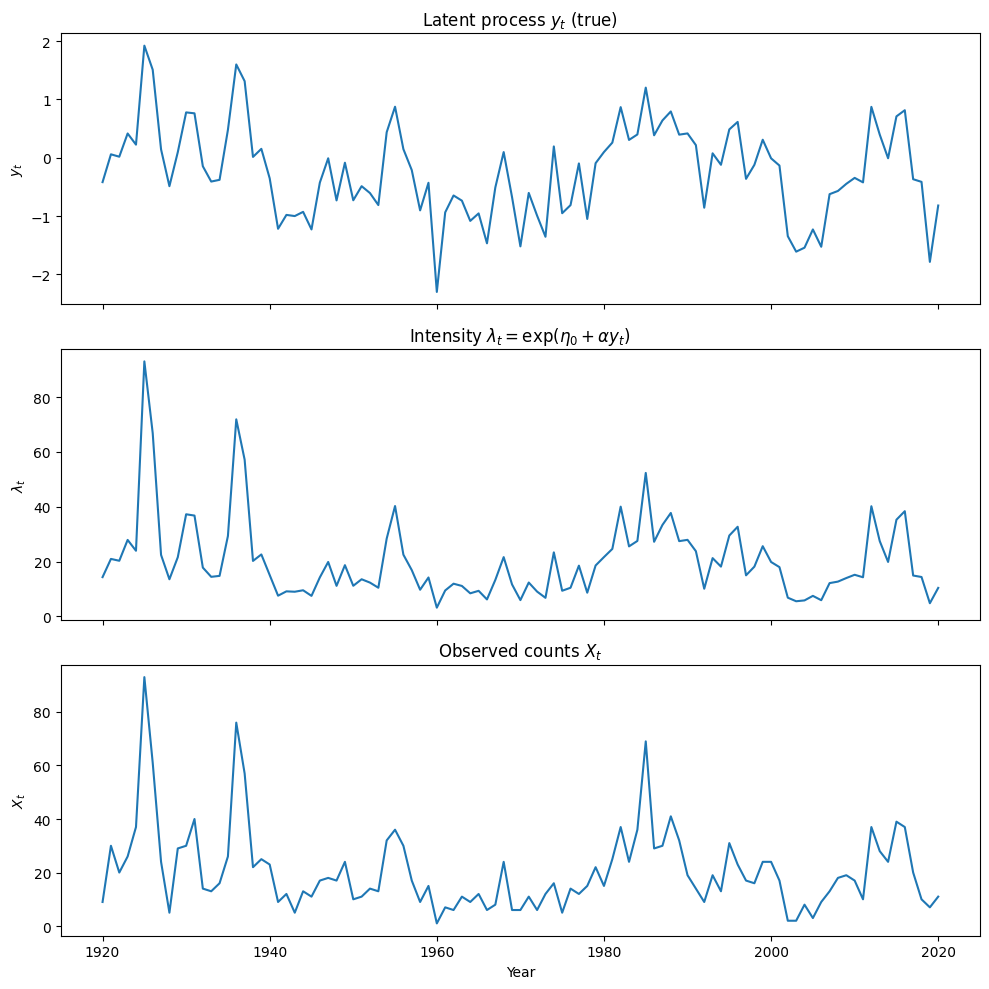

In [27]:
# =========================
# 6. プロット
# =========================
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(df_sim.index, df_sim["y_true"])
axes[0].set_title("Latent process $y_t$ (true)")
axes[0].set_ylabel("$y_t$")

axes[1].plot(df_sim.index, df_sim["lambda_true"])
axes[1].set_title("Intensity $\\lambda_t = \\exp(\\eta_0 + \\alpha y_t)$")
axes[1].set_ylabel("$\\lambda_t$")

axes[2].plot(df_sim.index, df_sim["X"])
axes[2].set_title("Observed counts $X_t$")
axes[2].set_ylabel("$X_t$")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

===to DatetimeIndex===
<class 'pandas.DatetimeIndex'>
====DatetimeIndex====


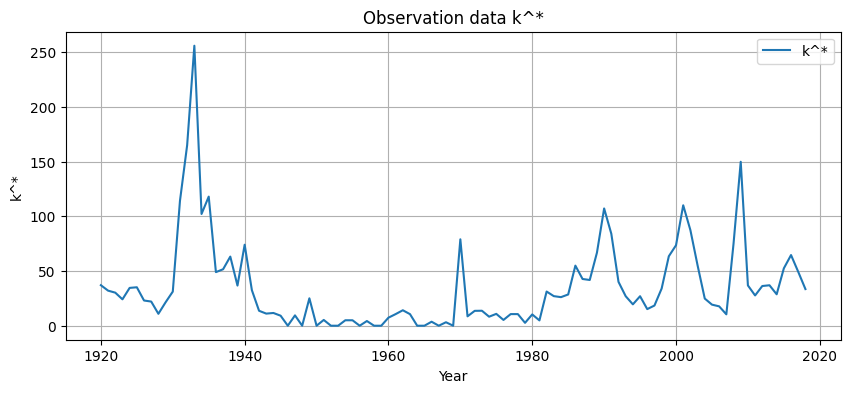

In [28]:
# 実データ（参考）
from pathlib import Path
csv_path_y = Path("init_y/y.csv")
init_y = pd.read_csv(csv_path_y)
init_y["Year"] = pd.to_datetime(init_y["Year"])
init_y = init_y.set_index("Year")

csv_path = Path("../data/raw/M.csv")
df = pd.read_csv(csv_path)

# set index to Year
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df = df.set_index("Year")
print("===to DatetimeIndex===")
print(type(df.index))
print("====DatetimeIndex====")

df["ALL_norm"] = df["D_ALL"] / df["ALL"] * 3000

plt.figure(figsize=(10, 4))

plt.plot(df["ALL_norm"].index, df["ALL_norm"], label="k^*")
plt.title("Observation data k^*")
plt.xlabel("Year")
plt.ylabel("k^*")

plt.legend()
plt.grid(True)

plt.show()

## 初期値の決め方
1. Poisson MLEで $\eta_0$, $\alpha$ を推定
2. $y_t = \frac{(log X_t − η_0)}{\alpha}$ で復元
3. $ACF(y)$ から
   $\theta_{init} = \rho(1)$, 
   $\gamma_{init}$ = log-log回帰
4. それを初期値としてベイズ推定

```python
estimate_init_eta_alpha(data)
restore_latent_y(data, eta0, alpha, c=0.5)
estimate_init_theta(y)
estimate_init_gamma(y, max_lag=10)

estimate_all_initial_params(data)
```

In [29]:
df_sim.head()

,y_true,lambda_true,X
Year,,,
1920-01-01,-0.418053,14.314746,9
1921-01-01,0.058647,20.960709,30
1922-01-01,0.017748,20.285989,20
1923-01-01,0.415799,27.892884,26
1924-01-01,0.224518,23.935113,37


In [30]:
import numpy as np
from scipy.optimize import minimize, curve_fit
from statsmodels.tsa.stattools import acf


# =========================================================
# 0. 基本ユーティリティ
# =========================================================

def _to_1d_count_array(data):
    """
    入力を 1 次元の非負カウント配列に変換する。
    """
    x = np.asarray(data, dtype=float).reshape(-1)

    if np.any(~np.isfinite(x)):
        raise ValueError("data に NaN または inf が含まれています。")

    if np.any(x < 0):
        raise ValueError("data は非負のカウント系列である必要があります。")

    return x


def _standardize(z, eps=1e-8):
    """
    平均0・分散1に標準化する。
    """
    z = np.asarray(z, dtype=float).reshape(-1)
    m = np.mean(z)
    s = np.std(z, ddof=0)

    if s < eps:
        return np.zeros_like(z)

    return (z - m) / s


def _numerical_hessian(func, x0, eps=1e-5):
    """
    中心差分による数値ヘッセ行列
    """
    x0 = np.asarray(x0, dtype=float)
    n = len(x0)
    hess = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ej = np.zeros(n)
            ei[i] = eps
            ej[j] = eps

            f_pp = func(x0 + ei + ej)
            f_pm = func(x0 + ei - ej)
            f_mp = func(x0 - ei + ej)
            f_mm = func(x0 - ei - ej)

            hess[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * eps * eps)

    return hess


# =========================================================
# 1. eta0, alpha の初期値推定
# =========================================================

def estimate_init_eta_alpha(data, c=0.5, alpha_bounds=(1e-3, 5.0)):
    """
    eta0, alpha の初期値と、それに対応する粗い prior scale を返す。

    方針
    ----
    1. z_t = standardized(log(X_t + c)) を proxy latent とみなす
    2. X_t ~ Poisson(exp(eta0 + alpha * z_t)) の Poisson 尤度を最大化
    3. 数値ヘッセ行列の逆行列から eta0, alpha の標準誤差を近似

    Returns
    -------
    eta0_init : float
    alpha_init : float
    sigma_eta0 : float
    sigma_alpha : float
    """
    x = _to_1d_count_array(data)

    z_raw = np.log(x + c)
    z = _standardize(z_raw)

    mean_x = np.mean(x)
    var_x = np.var(x, ddof=0)

    eta0_guess = float(np.log(mean_x + 1e-8))

    ratio = var_x / (mean_x + 1e-8)
    if ratio <= 1.0:
        alpha_guess = 0.3
    else:
        alpha_guess = min(1.0, 0.3 + 0.2 * np.log(ratio))

    alpha_guess = float(np.clip(alpha_guess, alpha_bounds[0], alpha_bounds[1]))

    def objective(params):
        eta0, log_alpha = params
        alpha = np.exp(log_alpha)

        linpred = eta0 + alpha * z
        linpred = np.clip(linpred, -30.0, 30.0)
        mu = np.exp(linpred)

        # 定数項 log(x!) は省略
        return np.sum(mu - x * linpred)

    init = np.array([eta0_guess, np.log(alpha_guess)], dtype=float)

    result = minimize(
        objective,
        init,
        method="L-BFGS-B",
        bounds=[
            (None, None),
            (np.log(alpha_bounds[0]), np.log(alpha_bounds[1])),
        ],
    )

    if not result.success:
        return eta0_guess, alpha_guess, 0.5, 0.3

    eta0_init = float(result.x[0])
    log_alpha_init = float(result.x[1])
    alpha_init = float(np.exp(log_alpha_init))

    try:
        hess = _numerical_hessian(objective, result.x, eps=1e-5)
        cov = np.linalg.inv(hess)

        sigma_eta0 = float(np.sqrt(max(cov[0, 0], 1e-10)))

        sigma_log_alpha = float(np.sqrt(max(cov[1, 1], 1e-10)))
        sigma_alpha = float(alpha_init * sigma_log_alpha)

        sigma_eta0 = max(sigma_eta0, 1e-3)
        sigma_alpha = max(sigma_alpha, 1e-3)

    except Exception:
        sigma_eta0 = 0.5
        sigma_alpha = 0.3

    return eta0_init, alpha_init, sigma_eta0, sigma_alpha


# =========================================================
# 2. 潜在系列 y_t の復元
# =========================================================

def restore_latent_y(data, eta0, alpha, c=0.5, standardize=False):
    """
    観測カウントから潜在系列 y_t を復元する。

    数式
    ----
        y_t = (log(X_t + c) - eta0) / alpha

    Parameters
    ----------
    standardize : bool
        True の場合は平均0・分散1に標準化する。
        論文寄りに行くなら False 推奨。
    """
    x = _to_1d_count_array(data)

    if alpha <= 0:
        raise ValueError("alpha は正である必要があります。")

    y_raw = (np.log(x + c) - eta0) / alpha

    if standardize:
        return _standardize(y_raw)

    return y_raw


# =========================================================
# 3. exponential decay 用の theta 初期値推定
# =========================================================

def _exp_acf(h, theta):
    """
    ACF(h) = theta^h
    """
    return theta ** h


def estimate_init_theta(y, max_lag=20, theta_bounds=(1e-3, 0.999), fallback_theta=0.5):
    """
    復元系列 y から exponential decay 用の theta_init を推定し、
    あわせて sigma_log_l を返す。

    方針
    ----
    標本 ACF に対して
        ACF(h) ≈ theta^h
    を非線形最小二乗でフィットする。

    ここで
        l = -1 / log(theta)

    とおく。

    Returns
    -------
    theta_init : float
    sigma_log_l : float
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    T = len(y)

    if T < 5:
        theta_init = float(fallback_theta)
        l_init = -1.0 / np.log(theta_init)
        sigma_log_l = 0.5
        return theta_init, sigma_log_l

    max_lag = min(max_lag, T - 2)
    if max_lag < 2:
        theta_init = float(fallback_theta)
        l_init = -1.0 / np.log(theta_init)
        sigma_log_l = 0.5
        return theta_init, sigma_log_l

    acf_vals = acf(y, nlags=max_lag, fft=False)

    lags = np.arange(1, max_lag + 1, dtype=float)
    rho = np.asarray(acf_vals[1:max_lag + 1], dtype=float)

    mask = np.isfinite(rho)
    lags_fit = lags[mask]
    rho_fit = rho[mask]

    if len(lags_fit) < 3:
        theta_init = float(fallback_theta)
        l_init = -1.0 / np.log(theta_init)
        sigma_log_l = 0.5
        return theta_init, sigma_log_l

    try:
        p0 = [min(max(rho_fit[0], theta_bounds[0]), theta_bounds[1])]

        popt, pcov = curve_fit(
            _exp_acf,
            lags_fit,
            rho_fit,
            p0=p0,
            bounds=theta_bounds,
            maxfev=10000,
        )

        theta_init = float(popt[0])
        theta_init = float(np.clip(theta_init, theta_bounds[0], theta_bounds[1]))

        # l = -1 / log(theta)
        l_init = float(-1.0 / np.log(theta_init))

        if pcov is not None and pcov.shape == (1, 1) and np.isfinite(pcov[0, 0]):
            se_theta = float(np.sqrt(max(pcov[0, 0], 1e-10)))

            # log l = log(-1/log(theta))
            # d(log l)/d theta = -1 / (theta * log(theta))
            deriv = -1.0 / (theta_init * np.log(theta_init))
            sigma_log_l = float(abs(deriv) * se_theta)
            sigma_log_l = max(sigma_log_l, 1e-3)
        else:
            sigma_log_l = 0.5

        return theta_init, sigma_log_l

    except Exception:
        theta_init = float(fallback_theta)
        l_init = -1.0 / np.log(theta_init)
        sigma_log_l = 0.5
        return theta_init, sigma_log_l


# =========================================================
# 4. power-law decay 用の gamma 初期値推定
# =========================================================

def _power_acf(h, gamma):
    """
    ACF(h) = (1 + h)^(-gamma)
    """
    return (1.0 + h) ** (-gamma)


def estimate_init_gamma(
    y,
    max_lag=20,
    gamma_bounds=(1e-3, 3.0),
    fallback_gamma=0.7,
    fallback_sigma_log_gamma=0.5,
):
    """
    復元系列 y から power-law decay 用の gamma_init を推定し、
    あわせて sigma_log_gamma を返す。

    方針
    ----
    標本 ACF に対して
        ACF(h) ≈ (1+h)^(-gamma)
    を非線形最小二乗でフィットする。

    ※ log-log 回帰、重み付き回帰、複数窓中央値などは使わない。
    論文寄りのシンプルな初期値推定に寄せる。

    Returns
    -------
    gamma_init : float
    sigma_log_gamma : float
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    T = len(y)

    if T < 5:
        return float(fallback_gamma), float(fallback_sigma_log_gamma)

    max_lag = min(max_lag, T - 2)
    if max_lag < 2:
        return float(fallback_gamma), float(fallback_sigma_log_gamma)

    acf_vals = acf(y, nlags=max_lag, fft=False)

    lags = np.arange(1, max_lag + 1, dtype=float)
    rho = np.asarray(acf_vals[1:max_lag + 1], dtype=float)

    mask = np.isfinite(rho)
    lags_fit = lags[mask]
    rho_fit = rho[mask]

    if len(lags_fit) < 3:
        return float(fallback_gamma), float(fallback_sigma_log_gamma)

    try:
        popt, pcov = curve_fit(
            _power_acf,
            lags_fit,
            rho_fit,
            p0=[fallback_gamma],
            bounds=gamma_bounds,
            maxfev=10000,
        )

        gamma_init = float(popt[0])
        gamma_init = float(np.clip(gamma_init, gamma_bounds[0], gamma_bounds[1]))

        if pcov is not None and pcov.shape == (1, 1) and np.isfinite(pcov[0, 0]):
            se_gamma = float(np.sqrt(max(pcov[0, 0], 1e-10)))
            sigma_log_gamma = float(max(se_gamma / max(gamma_init, 1e-8), 1e-3))
        else:
            sigma_log_gamma = float(fallback_sigma_log_gamma)

        return gamma_init, sigma_log_gamma

    except Exception:
        return float(fallback_gamma), float(fallback_sigma_log_gamma)


# =========================================================
# 5. 初期値一括推定
# =========================================================

def estimate_all_initial_params(
    data,
    c=0.5,
    max_lag_theta=20,
    max_lag_gamma=20,
    standardize_y=False,
):
    """
    初期値と prior scale を一括推定する。

    手順
    ----
    1. eta0_init, alpha_init, sigma_eta0, sigma_alpha
    2. y_init を復元
    3. theta_init, sigma_log_l
    4. gamma_init, sigma_log_gamma

    Parameters
    ----------
    standardize_y : bool
        y を標準化するかどうか。
        論文寄りに行くなら False 推奨。

    Returns
    -------
    result : dict
        {
            "eta0_init": ...,
            "alpha_init": ...,
            "theta_init": ...,
            "gamma_init": ...,
            "l_init": ...,
            "y_init": np.ndarray,
            "sigma_eta0": ...,
            "sigma_alpha": ...,
            "sigma_log_l": ...,
            "sigma_log_gamma": ...
        }
    """
    eta0_init, alpha_init, sigma_eta0, sigma_alpha = estimate_init_eta_alpha(data, c=c)

    y_init = restore_latent_y(
        data,
        eta0=eta0_init,
        alpha=alpha_init,
        c=c,
        standardize=standardize_y,
    )

    theta_init, sigma_log_l = estimate_init_theta(
        y_init,
        max_lag=max_lag_theta,
    )

    gamma_init, sigma_log_gamma = estimate_init_gamma(
        y_init,
        max_lag=max_lag_gamma,
    )

    l_init = float(-1.0 / np.log(theta_init))

    return {
        "eta0_init": float(eta0_init),
        "alpha_init": float(alpha_init),
        "theta_init": float(theta_init),
        "gamma_init": float(gamma_init),
        "l_init": float(l_init),
        "y_init": np.asarray(y_init, dtype=float),
        "sigma_eta0": float(sigma_eta0),
        "sigma_alpha": float(sigma_alpha),
        "sigma_log_l": float(sigma_log_l),
        "sigma_log_gamma": float(sigma_log_gamma),
    }


# =========================================================
# 6. 使い方例
# =========================================================
#
# result = estimate_all_initial_params(
#     data=k_obs,
#     c=0.5,
#     max_lag_theta=20,
#     max_lag_gamma=20,
#     standardize_y=False,
# )
#
# print(result["eta0_init"])
# print(result["alpha_init"])
# print(result["theta_init"])
# print(result["gamma_init"])
# print(result["l_init"])

In [31]:
init_params = estimate_all_initial_params(df_sim["X"])

print("eta0_init       =", init_params["eta0_init"])
print("alpha_init      =", init_params["alpha_init"])
print("theta_init      =", init_params["theta_init"])
print("gamma_init      =", init_params["gamma_init"])
print("l_init          =", init_params["l_init"])
print("sigma_eta0      =", init_params["sigma_eta0"])
print("sigma_alpha     =", init_params["sigma_alpha"])
print("sigma_log_l     =", init_params["sigma_log_l"])
print("sigma_log_gamma =", init_params["sigma_log_gamma"])

eta0_init       = 2.772554629957956
alpha_init      = 0.7403460208099953
theta_init      = 0.5771290436675566
gamma_init      = 1.348555594483998
l_init          = 1.8192092029911526
sigma_eta0      = 0.027118713658641973
sigma_alpha     = 0.02433054779712997
sigma_log_l     = 0.104335280328455
sigma_log_gamma = 0.11992348228891188


In [32]:
print("===true===")
print("eta_0 = ", eta0)
print("lambda = " , np.exp(eta0))
print("alpha = ",alpha)
print("gamma = ",gamma)

print("===diff===")
print("△eta_0 = ", eta0 - init_params["eta0_init"])
print("△lambda = " , np.exp(eta0) -  np.exp(init_params["eta0_init"]))
print("△alpha = ",alpha - init_params["alpha_init"])
print("△gamma = ",gamma -  init_params["gamma_init"])

===true===
eta_0 =  2.995732273553991
lambda =  19.999999999999996
alpha =  0.8
gamma =  0.5
===diff===
△eta_0 =  0.22317764359603487
△lambda =  4.000545467211037
△alpha =  0.0596539791900047
△gamma =  -0.848555594483998


## Exponential-kernel model

$$
X_t \mid \eta_0,\alpha,\mathbf y
\sim
\text{Poisson}\!\left(\exp(\eta_0+\alpha y_t)\right)
$$

$$
\mathbf y \sim \mathcal N(\mathbf 0, K^{(\mathrm{exp})})
$$

$$
K^{(\mathrm{exp})}_{ij}
=
\exp\!\left(-\frac{|t_i-t_j|}{l}\right)
$$

$$
\theta = \exp(-1/l), \qquad
l = -\frac{1}{\log \theta}
$$

$$
\eta_0 \sim \mathcal N(\eta_0^{init}, c\sigma_{\eta_0}^2)
$$

$$
\alpha \sim \mathcal N^+(\alpha^{init}, c\sigma_{\alpha}^2)
$$

$$
\log l
\sim
\mathcal N\!\left(
\log\!\left(-\frac{1}{\log \theta^{init}}\right),
c\sigma_{l}^2
\right)
$$


In [33]:
def _make_distance_matrix(T):
    """
    |t_i - t_j| の距離行列を作る。
    """
    t = np.arange(T, dtype=float)
    dist = np.abs(t[:, None] - t[None, :])
    return dist

In [34]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt

def build_exp_kernel_model(data, init_params, prior_scale=1.0 , jitter=1e-6):
    """
    Exponential-kernel Poisson latent GP model

    Model
    -----
    X_t | eta0, alpha, y ~ Poisson(exp(eta0 + alpha y_t))
    y ~ N(0, K_exp)
    K_exp[i,j] = exp(-|t_i - t_j| / l)

    Priors
    ------
    eta0 ~ Normal(eta0_init, sigma_eta0^2)
    alpha ~ TruncatedNormal(alpha_init, sigma_alpha^2, lower=0)
    log_l ~ Normal(log(l_init), sigma_log_l^2)
    """
    x = _to_1d_count_array(data)
    T = len(x)
    dist = _make_distance_matrix(T)
    y_init = np.asarray(init_params["y_init"], dtype=float).reshape(-1)

    if len(y_init) != T:
        raise ValueError("init_params['y_init'] の長さが data と一致していません。")

    eta0_init = float(init_params["eta0_init"])
    alpha_init = float(init_params["alpha_init"])
    l_init = float(init_params["l_init"])

    sigma_eta0 = float(init_params["sigma_eta0"])
    sigma_alpha = float(init_params["sigma_alpha"])
    sigma_log_l = float(init_params["sigma_log_l"])

    coords = {"time": np.arange(T)}

    with pm.Model(coords=coords) as model:
        x_obs = pm.Data("x_obs", x, dims="time")
    
        eta0 = pm.Normal(
            "eta0",
            mu=eta0_init,
            sigma=prior_scale * sigma_eta0,
        )
    
        alpha = pm.TruncatedNormal(
            "alpha",
            mu=alpha_init,
            sigma=prior_scale * sigma_alpha,
            lower=0.0,
        )
    
        log_l = pm.Normal(
            "log_l",
            mu=np.log(l_init),
            sigma=prior_scale * sigma_log_l,
        )
    
        l = pm.Deterministic("l", pt.exp(log_l))
        theta = pm.Deterministic("theta", pt.exp(-1.0 / l))
        lambda0 = pm.Deterministic("lambda0", pt.exp(eta0))
    
        K = pt.exp(-dist / l) + jitter * pt.eye(T)
    
        y = pm.MvNormal(
            "y",
            mu=pt.zeros(T),
            cov=K,
            dims="time",
        )
    
        mu = pm.Deterministic(
            "mu",
            pt.exp(eta0 + alpha * y),
            dims="time",
        )
    
        pm.Poisson(
            "x",
            mu=mu,
            observed=x_obs,
            dims="time",
        )
    
    return model

C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [35]:
# モデル構築
model_exp = build_exp_kernel_model(df_sim["X"], init_params , prior_scale = 5.0)

with model_exp:
    trace_exp = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        initvals={
            "eta0": init_params["eta0_init"],
            "alpha": init_params["alpha_init"],
            "log_l": np.log(init_params["l_init"]),
            "y": init_params["y_init"],
        },
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
C:\Users\h20s1\workspace\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_l, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 58 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [36]:
import arviz as az

az.summary(trace_exp, var_names=["eta0", "alpha", "log_l", "l", "theta", "lambda0"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta0,2.781,0.101,2.582,2.968,0.009,0.005,118.0,183.0,1.02
alpha,0.674,0.067,0.555,0.797,0.005,0.002,200.0,552.0,1.02
log_l,0.916,0.260,0.470,1.424,0.013,0.006,382.0,738.0,1.01
l,2.586,0.686,1.437,3.848,0.036,0.021,382.0,738.0,1.01
theta,0.665,0.070,0.538,0.788,0.003,0.001,382.0,738.0,1.01
lambda0,16.211,1.652,13.190,19.405,0.152,0.087,118.0,183.0,1.02


In [37]:
print("===true===")
print("eta_0 = ", eta0)
print("lambda = " , np.exp(eta0))
print("alpha = ",alpha)
print("gamma = ",gamma)

===true===
eta_0 =  2.995732273553991
lambda =  19.999999999999996
alpha =  0.8
gamma =  0.5


## Power-law-kernel model

$$
X_t \mid \eta_0,\alpha,\mathbf y
\sim
\text{Poisson}\!\left(\exp(\eta_0+\alpha y_t)\right)
$$

$$
\mathbf y \sim \mathcal N(\mathbf 0, K^{(\mathrm{pow})})
$$

$$
K^{(\mathrm{pow})}_{ij}
=
\frac{1}{(1+|t_i-t_j|)^\gamma}
$$

$$
\eta_0 \sim \mathcal N(\eta_0^{init}, c\sigma_{\eta_0}^2)
$$

$$
\alpha \sim \mathcal N^+(\alpha^{init}, c\sigma_{\alpha}^2)
$$

$$
\log \gamma \sim \mathcal N(\log \gamma^{init}, c\sigma_{\gamma}^2)
$$

In [38]:
def build_power_kernel_model(data, init_params, prior_scale=1.0 , jitter=1e-6):
    """
    Power-law-kernel Poisson latent GP model

    Model
    -----
    X_t | eta0, alpha, y ~ Poisson(exp(eta0 + alpha y_t))
    y ~ N(0, K_pow)
    K_pow[i,j] = 1 / (1 + |t_i - t_j|)^gamma

    Priors
    ------
    eta0 ~ Normal(eta0_init, sigma_eta0^2)
    alpha ~ TruncatedNormal(alpha_init, sigma_alpha^2, lower=0)
    log_gamma ~ Normal(log(gamma_init), sigma_log_gamma^2)
    """
    x = _to_1d_count_array(data)
    T = len(x)
    dist = _make_distance_matrix(T)
    y_init = np.asarray(init_params["y_init"], dtype=float).reshape(-1)

    if len(y_init) != T:
        raise ValueError("init_params['y_init'] の長さが data と一致していません。")

    eta0_init = float(init_params["eta0_init"])
    alpha_init = float(init_params["alpha_init"])
    gamma_init = float(init_params["gamma_init"])

    sigma_eta0 = float(init_params["sigma_eta0"])
    sigma_alpha = float(init_params["sigma_alpha"])
    sigma_log_gamma = float(init_params["sigma_log_gamma"])

    coords = {"time": np.arange(T)}

    with pm.Model(coords=coords) as model:
        # data
        x_obs = pm.Data("x_obs", x, dims="time")

        # priors
        eta0 = pm.Normal(
            "eta0",
            mu=eta0_init,
            sigma=prior_scale * sigma_eta0
        )

        alpha = pm.TruncatedNormal(
            "alpha",
            mu=alpha_init,
            sigma=prior_scale * sigma_alpha,
            lower=0.0
        )

        log_gamma = pm.Normal(
            "log_gamma",
            mu=np.log(gamma_init),
            sigma=prior_scale * sigma_log_gamma
        )

        # transformed parameters
        gamma = pm.Deterministic("gamma", pt.exp(log_gamma))
        lambda0 = pm.Deterministic("lambda0", pt.exp(eta0))

        # covariance matrix
        K = (1.0 + dist) ** (-gamma) + jitter * pt.eye(T)

        # latent process
        y = pm.MvNormal(
            "y",
            mu=pt.zeros(T),
            cov=K,
            dims="time",
        )

        # intensity and likelihood
        mu = pm.Deterministic(
            "mu",
            pt.exp(eta0 + alpha * y),
            dims="time",
        )

        pm.Poisson(
            "x",
            mu=mu,
            observed=x_obs,
            dims="time",
        )

    return model

In [39]:
model_pow = build_power_kernel_model(df_sim["X"], init_params , prior_scale = 5.0)

with model_pow:
    trace_pow = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        initvals={
            "eta0": init_params["eta0_init"],
            "alpha": init_params["alpha_init"],
            "log_gamma": np.log(init_params["gamma_init"]),
            "y": init_params["y_init"],
        },
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 69 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [40]:
# 指数の推定サマリー
az.summary(trace_exp, var_names=["lambda0" , "alpha" , "theta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda0,16.211,1.652,13.190,19.405,0.152,0.087,118.0,183.0,1.02
alpha,0.674,0.067,0.555,0.797,0.005,0.002,200.0,552.0,1.02
theta,0.665,0.070,0.538,0.788,0.003,0.001,382.0,738.0,1.01


In [41]:
# べきの推定サマリー
az.summary(trace_pow, var_names=["lambda0" , "alpha", "gamma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda0,16.156,1.795,13.039,19.836,0.146,0.077,151.0,398.0,1.01
alpha,0.696,0.074,0.558,0.826,0.005,0.003,215.0,445.0,1.02
gamma,0.705,0.218,0.330,1.111,0.011,0.005,328.0,481.0,1.00


In [42]:
print("===true===")
print("lambda = " , lambda0)
print("alpha = ",alpha)
print("gamma = ",gamma)

===true===
lambda =  20.0
alpha =  0.8
gamma =  0.5


### 現状
- 強度モデルは正しく回収
- 相関構造は識別困難
- 有限データではpower-lawは過大評価されやすい

## LFOでのモデル評価

In [43]:
import numpy as np
import pandas as pd
import arviz as az

# -----------------------------
# 数値安定な log(mean(exp(a)))
# -----------------------------
def logmeanexp(a, axis=None):
    a = np.asarray(a, dtype=float)
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.mean(np.exp(a - a_max), axis=axis, keepdims=True))
    return np.squeeze(out, axis=axis)


# -----------------------------
# idata.posterior からサンプル抽出
# shape: (samples, ...)
# -----------------------------
def posterior_array(idata, var_name):
    arr = idata.posterior[var_name].values
    # (chain, draw, ...) -> (sample, ...)
    return arr.reshape(-1, *arr.shape[2:])


# -----------------------------
# LFO 共通ドライバ
# build_and_sample_fn:
#   x_train, init_params, time_train -> (model, idata) or idata
#
# log_pred_fn:
#   idata, x_train, x_next, time_train -> scalar
# -----------------------------
def compute_lfo(
    x,
    time_index,
    init_params,
    build_and_sample_fn,
    log_pred_fn,
    t0_grid=None,
    verbose=True,
):
    x = np.asarray(x, dtype=np.int64)
    time_index = np.asarray(time_index)

    T = len(x)
    if t0_grid is None:
        t0_grid = list(range(max(10, T // 2), T - 1))

    rows = []

    for t in t0_grid:
        if t >= T - 1:
            continue

        x_train = x[:t + 1]
        x_next = int(x[t + 1])
        time_train = time_index[:t + 1]

        out = build_and_sample_fn(
            x_train=x_train,
            init_params=init_params,
            time_train=time_train,
        )
        idata = out[1] if isinstance(out, tuple) else out

        lp = log_pred_fn(
            idata=idata,
            x_train=x_train,
            x_next=x_next,
            time_train=time_train,
        )

        rows.append({
            "t_end": t,
            "train_end_time": time_index[t],
            "test_time": time_index[t + 1],
            "x_next": x_next,
            "log_pred": float(lp),
        })

        if verbose:
            print(
                f"[LFO] t={t:3d} "
                f"train_end={time_index[t]} "
                f"test={time_index[t+1]} "
                f"x_next={x_next:3d} "
                f"log_pred={lp:.4f}"
            )

    df_lfo = pd.DataFrame(rows)
    lfo_total = df_lfo["log_pred"].sum()

    return lfo_total, df_lfo

In [44]:
# Poissonのlog pmf
from scipy.special import gammaln

def poisson_logpmf(x, lam):
    lam = np.asarray(lam, dtype=float)
    return x * np.log(lam) - lam - gammaln(x + 1.0)

In [45]:
# 指数減衰モデル用の1期先予測密度
def log_pred_exp_poisson(
    idata,
    x_train,
    x_next,
    time_train,
    n_post=500,
    n_latent=30,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)

    eta0 = posterior_array(idata, "eta0")
    alpha = posterior_array(idata, "alpha")
    theta = posterior_array(idata, "theta")
    y = posterior_array(idata, "y")   # shape = (S, T_train)

    S = len(eta0)
    if S > n_post:
        idx = rng.choice(S, size=n_post, replace=False)
        eta0 = eta0[idx]
        alpha = alpha[idx]
        theta = theta[idx]
        y = y[idx]

    y_last = y[:, -1]
    sd_next = np.sqrt(np.maximum(1.0 - theta**2, 1e-10))
    mu_next = theta * y_last

    # 各 posterior sample ごとに latent y_{t+1} をさらに積分
    log_ps = []

    for s in range(len(eta0)):
        y_next_draws = rng.normal(
            loc=mu_next[s],
            scale=sd_next[s],
            size=n_latent
        )
        lam_draws = np.exp(eta0[s] + alpha[s] * y_next_draws)
        loglik_draws = poisson_logpmf(x_next, lam_draws)

        # p(x_{t+1}| posterior sample s) を latent で平均
        log_ps.append(logmeanexp(loglik_draws))

    # posterior でも平均
    return float(logmeanexp(np.array(log_ps)))

In [46]:
# べき減衰 GP 用の 1期先予測密度
def power_kernel(t1, t2, gamma):
    t1 = np.asarray(t1, dtype=float)
    t2 = np.asarray(t2, dtype=float)
    dist = np.abs(t1[:, None] - t2[None, :])
    return (1.0 + dist) ** (-gamma)


def log_pred_pow_poisson(
    idata,
    x_train,
    x_next,
    time_train,
    n_post=300,
    n_latent=30,
    jitter=1e-6,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)

    eta0 = posterior_array(idata, "eta0")
    alpha = posterior_array(idata, "alpha")
    gamma = posterior_array(idata, "gamma")
    y = posterior_array(idata, "y")   # shape = (S, T_train)

    S = len(eta0)
    if S > n_post:
        idx = rng.choice(S, size=n_post, replace=False)
        eta0 = eta0[idx]
        alpha = alpha[idx]
        gamma = gamma[idx]
        y = y[idx]

    t_train = np.asarray(time_train, dtype=float)
    t_next = np.array([t_train[-1] + 1.0], dtype=float)

    log_ps = []

    for s in range(len(eta0)):
        g = float(gamma[s])

        K_tt = power_kernel(t_train, t_train, g)
        K_tt = K_tt + jitter * np.eye(len(t_train))

        k_star = power_kernel(t_train, t_next, g).reshape(-1)   # shape=(T,)
        k_ss = power_kernel(t_next, t_next, g)[0, 0] + jitter

        # 条件付き平均・分散
        K_inv_y = np.linalg.solve(K_tt, y[s])
        K_inv_k = np.linalg.solve(K_tt, k_star)

        mu_star = k_star @ K_inv_y
        var_star = k_ss - k_star @ K_inv_k
        var_star = max(var_star, 1e-10)

        y_next_draws = rng.normal(
            loc=mu_star,
            scale=np.sqrt(var_star),
            size=n_latent
        )

        lam_draws = np.exp(eta0[s] + alpha[s] * y_next_draws)
        loglik_draws = poisson_logpmf(x_next, lam_draws)

        log_ps.append(logmeanexp(loglik_draws))

    return float(logmeanexp(np.array(log_ps)))

In [47]:
# 指数
def fit_exp_for_lfo(x_train, init_params, time_train):
    T_train = len(x_train)

    init_params_fold = dict(init_params)
    init_params_fold["y_init"] = np.asarray(init_params["y_init"], dtype=float)[:T_train]

    model = build_exp_kernel_model(
        data=x_train,
        init_params=init_params_fold,
        prior_scale = 5.0,
    )

    with model:
        idata = pm.sample(
            draws=1000,
            tune=1000,
            chains=2,
            target_accept=0.9,
            progressbar=False,
            return_inferencedata=True,
        )

    return model, idata

# べき
def fit_pow_for_lfo(x_train, init_params, time_train):
    T_train = len(x_train)

    init_params_fold = dict(init_params)
    init_params_fold["y_init"] = np.asarray(init_params["y_init"], dtype=float)[:T_train]

    model = build_power_kernel_model(
        data=x_train,
        init_params=init_params_fold,
        prior_scale = 5.0,
    )

    with model:
        idata = pm.sample(
            draws=1000,
            tune=1000,
            chains=2,
            target_accept=0.9,
            progressbar=False,
            return_inferencedata=True,
        )

    return model, idata

In [48]:
x = df_sim["X"].to_numpy(dtype=np.int64)
time_index = np.arange(len(x), dtype=float)

lfo_exp_total, lfo_exp_df = compute_lfo(
    x=x,
    time_index=time_index,
    init_params=init_params,
    build_and_sample_fn=fit_exp_for_lfo,
    log_pred_fn=log_pred_exp_poisson,
    t0_grid=list(range(50, len(x)-1, 2)),
    verbose=True,
)

print("EXP LFO total =", lfo_exp_total)
print(lfo_exp_df.head())

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_l, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


[LFO] t= 50 train_end=50.0 test=51.0 x_next= 11 log_pred=-2.9382


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_l, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 30 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 52 train_end=52.0 test=53.0 x_next= 12 log_pred=-3.0319


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_l, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 30 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


...

[LFO] t= 94 train_end=94.0 test=95.0 x_next= 39 log_pred=-4.6614


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_l, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 48 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 96 train_end=96.0 test=97.0 x_next= 20 log_pred=-3.5167


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_l, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 98 train_end=98.0 test=99.0 x_next=  7 log_pred=-2.9509
EXP LFO total = -89.78936324814339
   t_end  train_end_time  test_time  x_next  log_pred
0     50            50.0       51.0      11 -2.938185
1     52            52.0       53.0      12 -3.031886
2     54            54.0       55.0       5 -3.594468
3     56            56.0       57.0      12 -2.995653
4     58            58.0       59.0      22 -3.707874


In [49]:
x = df_sim["X"].to_numpy(dtype=np.int64)
time_index = np.arange(len(x), dtype=float)

t0_grid = list(range(50, len(x) - 1, 2))

lfo_pow_total, lfo_pow_df = compute_lfo(
    x=x,
    time_index=time_index,
    init_params=init_params,
    build_and_sample_fn=fit_pow_for_lfo,
    log_pred_fn=log_pred_pow_poisson,
    t0_grid=t0_grid,
    verbose=True,
)

print("POW LFO total =", lfo_pow_total)
print(lfo_pow_df.head())

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 31 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 50 train_end=50.0 test=51.0 x_next= 11 log_pred=-2.9430


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 32 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 52 train_end=52.0 test=53.0 x_next= 12 log_pred=-3.0668


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 33 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


...

[LFO] t= 94 train_end=94.0 test=95.0 x_next= 39 log_pred=-4.7021


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 61 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 96 train_end=96.0 test=97.0 x_next= 20 log_pred=-3.5101


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 68 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[LFO] t= 98 train_end=98.0 test=99.0 x_next=  7 log_pred=-3.1880
POW LFO total = -90.79250918516173
   t_end  train_end_time  test_time  x_next  log_pred
0     50            50.0       51.0      11 -2.943035
1     52            52.0       53.0      12 -3.066817
2     54            54.0       55.0       5 -3.356805
3     56            56.0       57.0      12 -2.989994
4     58            58.0       59.0      22 -3.797881


In [50]:
df_lfo_compare = pd.DataFrame({
    "model": ["exp_gp", "pow_gp"],
    "LFO_total": [lfo_exp_total, lfo_pow_total],
    "n_folds": [len(lfo_exp_df), len(lfo_pow_df)],
})

df_lfo_compare["LFO_mean"] = (
    df_lfo_compare["LFO_total"] / df_lfo_compare["n_folds"]
)

best_lfo = df_lfo_compare["LFO_total"].max()
df_lfo_compare["LFO_diff"] = df_lfo_compare["LFO_total"] - best_lfo

print(df_lfo_compare.sort_values("LFO_total", ascending=False).round(3))

    model  LFO_total  n_folds  LFO_mean  LFO_diff
0  exp_gp    -89.789       25    -3.592     0.000
1  pow_gp    -90.793       25    -3.632    -1.003


もう少しちゃんとやるなら
$$
\text{exp model}
\;\xrightarrow[\text{sc を複数試す}]{\text{LFO}}\;
\text{best exp}
$$

$$
\text{power model}
\;\xrightarrow[\text{sc を複数試す}]{\text{LFO}}\;
\text{best power}
$$

$$
\text{LFO}(\text{best exp})
\;\;\text{vs}\;\;
\text{LFO}(\text{best power})
$$

powerの予測性能が高いと判断されたなら

- 「このデータでは、LFO の観点から power-law decay model の方が支持された」
- 「少なくとも予測性能では exponential より power-law が優れていた」
- 「論文と整合的な結果になった」

## NBへの導入
NBを導入して期待される変化
- $\gamma$の推定が安定
- LFO改善
- テールが合う
- スパイク再現が良くなる